# Forecasting using RNN networks

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
data.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


## ARIMA model - baseline 

In [4]:
# !pip install --upgrade numpy==1.26.4

In [5]:
# Copy the original dataset 
data_arima = data.copy()

# Apply First Differencing
data_arima['close_diff'] = data_arima['close'].diff()

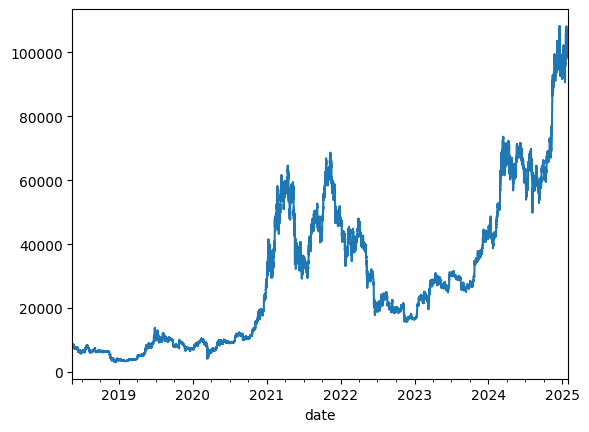

In [6]:
data_arima['close'].plot();

In [7]:
# ADF Test for Stationarity
result_diff = adfuller(data_arima['close_diff'].dropna())
print(f"ADF Test Statistic: {result_diff[0]}")
print(f"p-value: {result_diff[1]}")

# If data is still non-stationary, consider second differencing
if result_diff[1] > 0.05:
    print("Data is non-stationary. Consider second differencing.")
else:
    print("Data is stationary.")

ADF Test Statistic: -30.94015531837786
p-value: 0.0
Data is stationary.


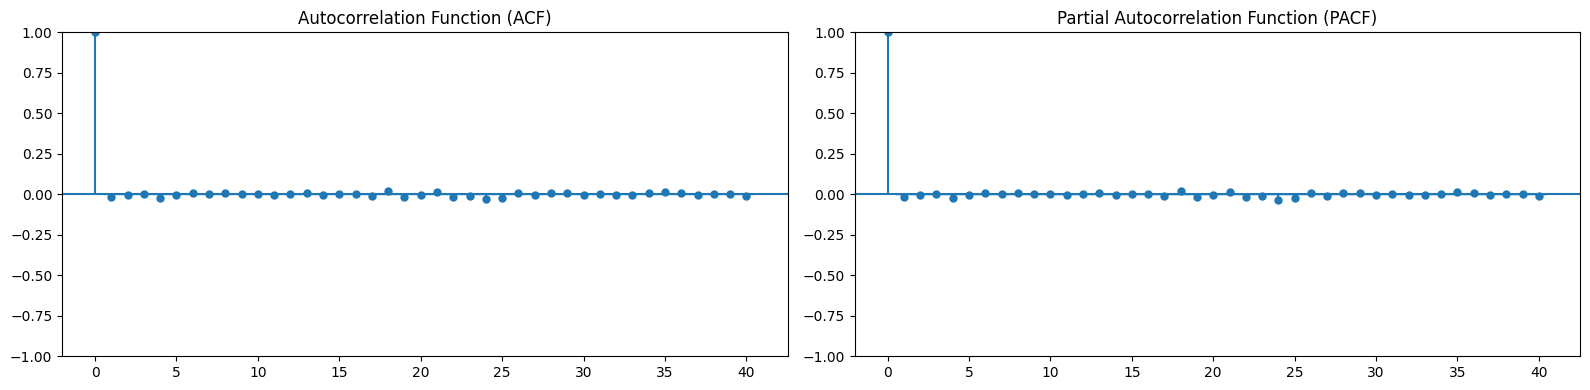

In [8]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(data_arima['close_diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(data_arima['close_diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

### Forecasting

In [9]:
# Split data into train and test
train_size = int(len(data_arima) * 0.8)
arima_train, arima_test = data_arima.iloc[:train_size], data_arima.iloc[train_size:]

# Fit ARIMA model
arima_model = ARIMA(arima_train["close"], order=(1,1,1))
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                47074
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -318418.800
Date:                Sat, 01 Feb 2025   AIC                         636843.600
Time:                        22:04:57   BIC                         636869.878
Sample:                    05-15-2018   HQIC                        636851.854
                         - 09-27-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1029      0.196      0.525      0.599      -0.281       0.487
ma.L1         -0.1124      0.196     -0.574      0.566      -0.496       0.271
sigma2      4.396e+04     67.858    647.772      0.0

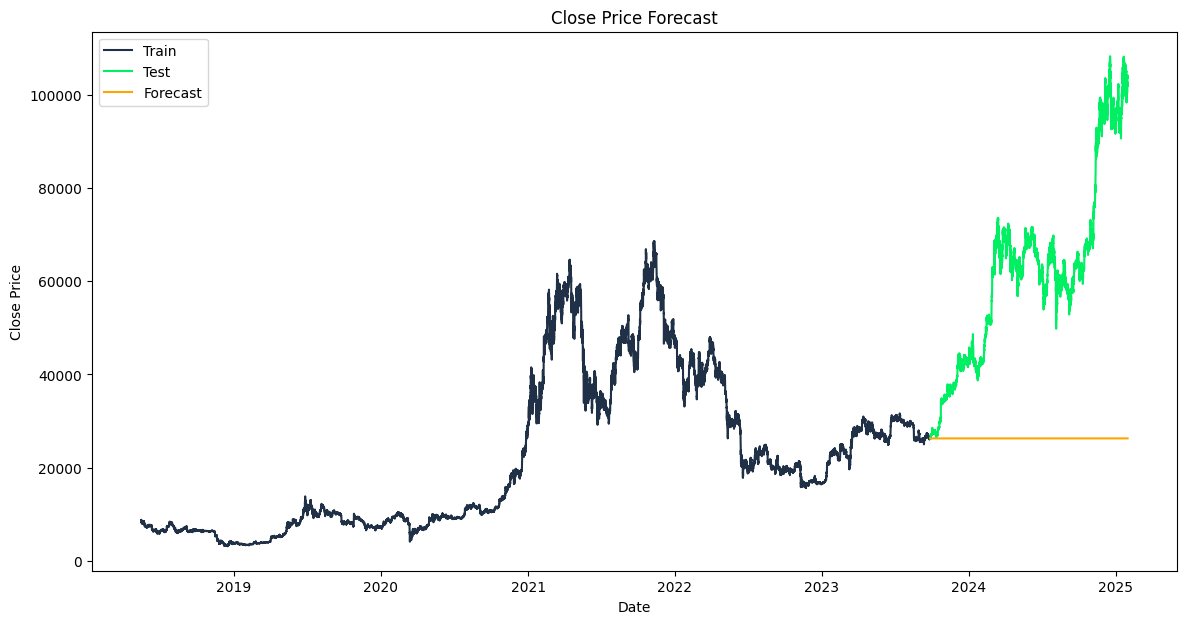

In [10]:
# Forecast
forecast = arima_model_fit.forecast(steps=len(arima_test))

# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(arima_train.index, arima_train["close"], label='Train', color='#203147')
plt.plot(arima_test.index, arima_test["close"], label='Test', color='#01ef63')
plt.plot(arima_test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [11]:
# Evaluate model statistics
print(f"AIC: {arima_model_fit.aic}")
print(f"BIC: {arima_model_fit.bic}")

forecast = forecast[:len(arima_test)]
arima_test_close = arima_test["close"][:len(forecast)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(arima_test_close, forecast))
print(f"RMSE: {rmse:.4f}")

AIC: 636843.5995857248
BIC: 636869.8779503264
RMSE: 40948.3933


In [12]:
# ## Method 2 using `auto_arima`: 

# # Find optimal ARIMA order
# stepwise_fit = auto_arima(data_arima['close'], seasonal=False, suppress_warnings=True)
# order = stepwise_fit.order
# print(f"Optimal ARIMA order: {order}")

# # Split data
# train_size = int(len(data_arima) * 0.8)  # 80% train, 20% test
# arima_train = data_arima.iloc[:train_size]
# arima_test = data_arima.iloc[train_size:]

# # Train ARIMA model
# arima_model = ARIMA(arima_train['close'], order=order)
# arima_model = arima_model.fit()
# print(arima_model.summary())

# # Make predictions
# arima_pred = arima_model.predict(start=len(arima_train), end=len(data_arima)-1)

# # Evaluate model performance
# arima_RMSE = sqrt(mean_squared_error(arima_test['close'], arima_pred))
# print(f"ARIMA RMSE: {arima_RMSE}")

# # Plot actual vs predicted prices
# plt.figure(figsize=(12, 6))
# arima_test['close'].plot(label="Actual Close Price", legend=True, linewidth=2)
# arima_pred.plot(label="ARIMA Predictions", linestyle="dashed", legend=True, linewidth=2)
# plt.xlabel("Date")
# plt.ylabel("Close Price")
# plt.title("ARIMA Model - Close Price Prediction")
# plt.legend()
# plt.show()

## Prepare Data for the RNNs

In [13]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [14]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [15]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## Implementing GRU

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,271 (12.78 KB)

 Trainable params: 3,271 (12.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0196 - val_loss: 0.0014
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026 - val_loss: 5.9225e-04
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018 - val_loss: 4.1561e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - val_loss: 3.4799e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 2.3793e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - val_loss: 5.0325e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.7392e-04 - val_loss: 4.0020e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.3496e-04 - val_loss: 6.3975e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4645e-04 - val_loss: 1.4232e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.3640e-04 - val_loss: 3.5016e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.1580e-04 - val_loss: 4.1

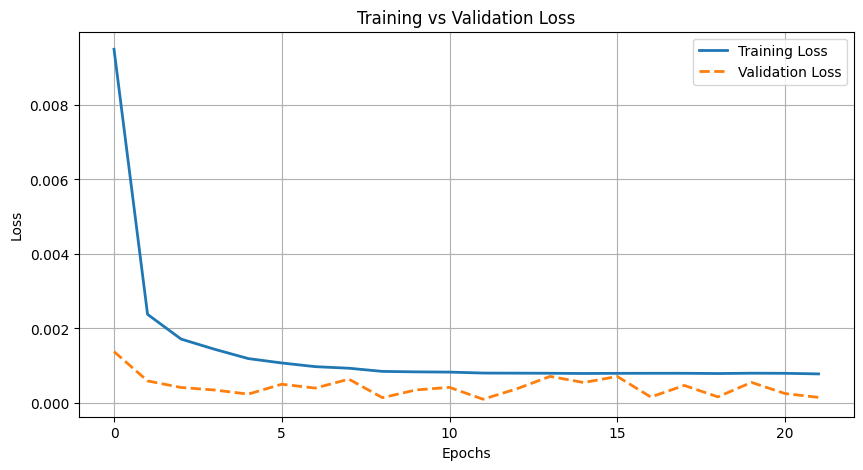

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step
Mean Absolute Error (MAE): 684.7001
Root Mean Squared Error (RMSE): 1056.0430
Mean Absolute Percentage Error (MAPE): 0.94%


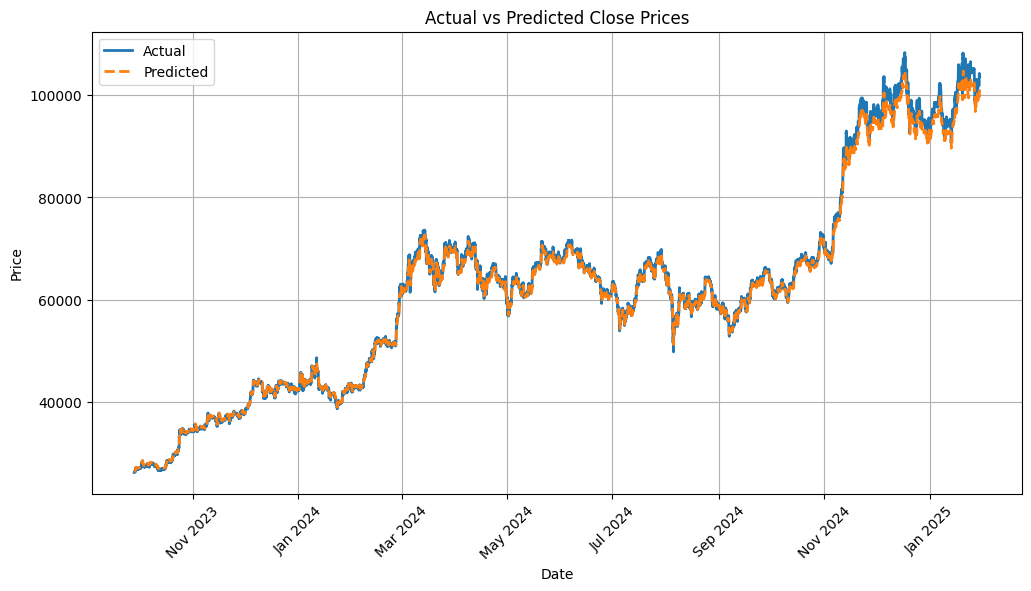

In [16]:
gru_model = Sequential()

# One GRU layer with dropout
gru_model.add(GRU(30, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.5))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

# Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model 
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
gru_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
gru_model.summary()

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=50,  # Increased epochs
                        batch_size=256, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform predictions
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Implementing LSTM

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,231 (16.53 KB)

 Trainable params: 4,231 (16.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0185 - val_loss: 0.0013
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 7.0290e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.7917e-04 - val_loss: 0.0011
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.2559e-04 - val_loss: 0.0011
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.8704e-04 - val_loss: 5.8925e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.9189e-04 - val_loss: 6.9346e-04
Epoch 12/50
184/184 ━━━━

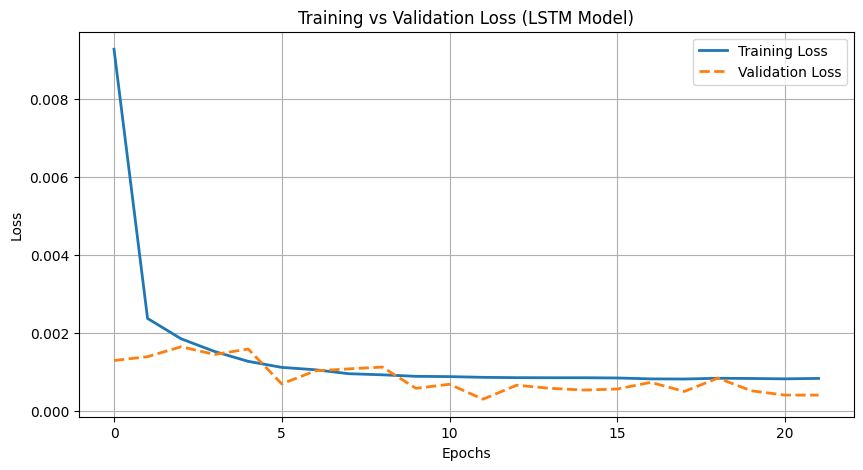

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step
Model Error Statistics:
Mean Absolute Error (MAE): 0.0128
Root Mean Squared Error (RMSE): 0.0176
Mean Absolute Percentage Error (MAPE): 1.97%


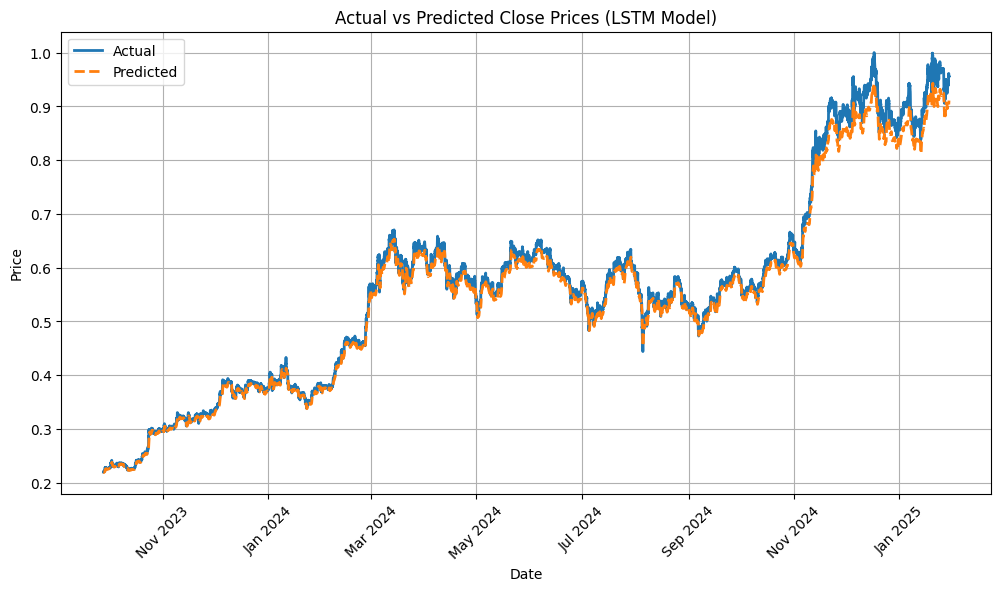

In [17]:
# LSTM Model 
lstm_model = Sequential()

# One LSTM layer
lstm_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.5))  

# Output layer
lstm_model.add(Dense(1))

# Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model 
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
lstm_model.summary()

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the LSTM model with Early Stopping
history = lstm_model.fit(X_train, y_train, 
                        epochs=50,  # Increased for better learning
                        batch_size=256,  # Increased for smoother validation loss
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (LSTM Model)')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform predictions
predicted_lstm = close_scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Hybrid LSTM-GRU model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 15, 30)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30)             │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,811 (38.32 KB)

 Trainable params: 9,811 (38.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0162 - val_loss: 0.0024
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0029 - val_loss: 8.0207e-04
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0018 - val_loss: 3.7401e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 4.4758e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 9.0680e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 6.6855e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010 - val_loss: 8.6260e-04
Epoch 12/50
184/1

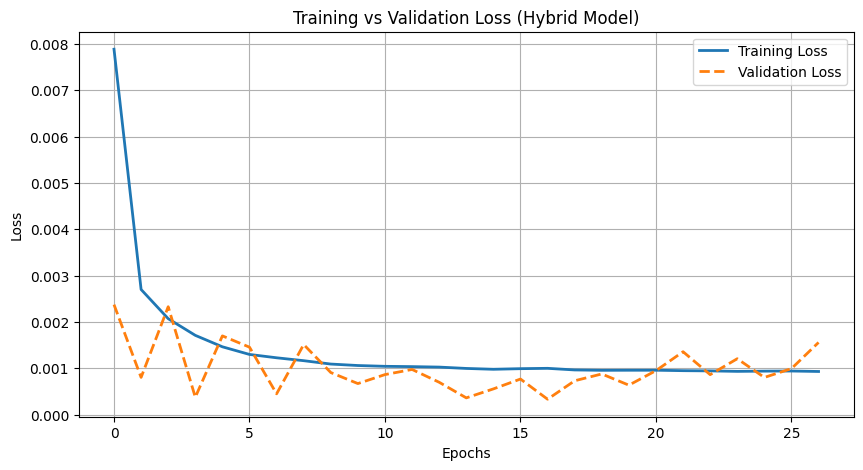

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Hybrid Model Error Statistics:
Mean Absolute Error (MAE): 0.0119
Root Mean Squared Error (RMSE): 0.0182
Mean Absolute Percentage Error (MAPE): 1.76%


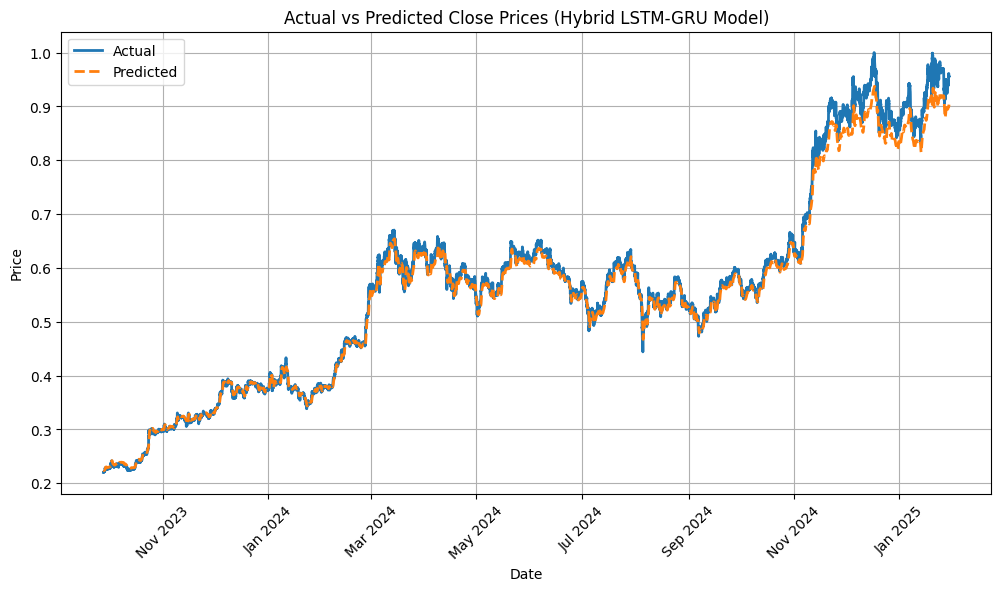

In [18]:
# Hybrid LSTM-GRU Model
hybrid_model = Sequential()

# One LSTM layer
hybrid_model.add(LSTM(30, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.5))

# One GRU layer 
hybrid_model.add(GRU(30, return_sequences=False, recurrent_dropout=0.2))  
hybrid_model.add(Dropout(0.5))

# Output layer
hybrid_model.add(Dense(1))

# Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005, 
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
hybrid_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=50,  
                                  batch_size=256,  # Increased batch size for stability
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid.reshape(-1, 1))  # Fixed reshaping issue
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Plot Actual vs Predicted Prices
date_index = pd.to_datetime(data.index[-len(y_test_actual):])
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()